<a href="https://colab.research.google.com/github/shubhamgupta1251-code/Statistical-Analysis-of-Factors-Affecting-Startup-Funding-in-India/blob/main/MSCP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## ============================================================
## STEP: Data Cleaning (Python / Google Colab version)
## Project: Statistical Analysis of Factors Affecting Startup
##          Funding in India
## Dataset: Indian Startup Funding (Kaggle)
## ============================================================

# If running in Colab, first upload startup_funding.csv:
# from google.colab import files
# uploaded = files.upload()

import pandas as pd
import numpy as np

## ---- 1. Load data ----------------------------------------------------------
df = pd.read_csv("startup_funding.csv")
print("Original dimensions:", df.shape)

## ---- 2. Drop columns not usable for analysis -------------------------------
# Sr No is just a row index; SubVertical and Remarks are >30%/85% missing
df = df.drop(columns=["Sr No", "SubVertical", "Remarks"])

## ---- 3. Clean the Amount column ---------------------------------------------
# Original values look like "20,00,00,000" or "undisclosed"
df["Amount_USD"] = (
    df["Amount in USD"]
    .astype(str)
    .str.strip()
    .str.replace(",", "", regex=False)
)
df["Amount_USD"] = pd.to_numeric(df["Amount_USD"], errors="coerce")  # "undisclosed" -> NaN

print("Non-missing funding amounts after cleaning:", df["Amount_USD"].notna().sum())

## ---- 4. Parse the date column -----------------------------------------------
df["Date_clean"] = pd.to_datetime(df["Date dd/mm/yyyy"], format="%d/%m/%Y", errors="coerce")
df["Year"] = df["Date_clean"].dt.year

print("Rows with unparseable dates (dropped later):", df["Date_clean"].isna().sum())

## ---- 5. Standardize City Location -------------------------------------------
city_map = {"Bengaluru": "Bangalore", "New Delhi": "Delhi", "Gurugram": "Gurgaon"}
df["City"] = df["City  Location"].astype(str).str.strip().replace(city_map)

## ---- 6. Standardize Investment Type ------------------------------------------
inv_map = {
    "Seed/ Angel Funding": "Seed Funding",
    "Seed / Angel Funding": "Seed Funding",
    "Seed/Angel Funding": "Seed Funding",
    "Seed / Angle Funding": "Seed Funding",   # typo variant in raw data
    "Angel / Seed Funding": "Seed Funding",
    "Seed Round": "Seed Funding",
    "Seed": "Seed Funding",
    "Private Equity Round": "Private Equity",
}
df["Investment_Type"] = (
    df["InvestmentnType"]
    .astype(str)
    .str.strip()
    .str.replace(r"\\+n", " ", regex=True)   # raw data has literal backslash-n, not a real newline
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .replace(inv_map)
)

## ---- 7. Standardize Industry Vertical, keep top 6, group rest as "Other" ----
ind_map = {
    "eCommerce": "ECommerce",
    "E-Commerce": "ECommerce",
    "E-commerce": "ECommerce",
    "Ecommerce": "ECommerce",
}
df["Industry"] = df["Industry Vertical"].astype(str).str.strip().replace(ind_map)

top_industries = (
    df.loc[df["Industry"] != "nan", "Industry"]
    .value_counts()
    .head(6)
    .index.tolist()
)
print("Top 6 industries kept:", top_industries)

df["Industry_grouped"] = np.where(df["Industry"].isin(top_industries), df["Industry"], "Other")

## ---- 7b. Fix a subtle bug: .astype(str) turns real missing values into the
##          literal text "nan", which would otherwise show up as a fake
##          category in City / Investment_Type / Industry. Convert back to
##          proper missing values (NaN) before analysis.
df["City"] = df["City"].replace("nan", np.nan)
df["Investment_Type"] = df["Investment_Type"].replace("nan", np.nan)
df["Industry"] = df["Industry"].replace("nan", np.nan)
df["Industry_grouped"] = np.where(df["Industry"].isna(), np.nan, df["Industry_grouped"])

## ---- 8. Final analysis-ready dataset -----------------------------------------
df_clean = df[[
    "Startup Name", "Date_clean", "Year", "City",
    "Industry_grouped", "Investment_Type", "Investors Name", "Amount_USD"
]].rename(columns={
    "Startup Name": "Startup_Name",
    "Date_clean": "Date",
    "Industry_grouped": "Industry",
    "Investors Name": "Investors_Name",
})

df_clean = df_clean.dropna(subset=["Date"])  # drop the ~7 rows with malformed dates

print("\nFinal cleaned dataset dimensions:", df_clean.shape)
print("Missing values per column:\n", df_clean.isna().sum())

## ---- 9. Save cleaned data ------------------------------------------------------
df_clean.to_csv("startup_funding_clean.csv", index=False)
print("\nSaved as startup_funding_clean.csv")

# In Colab, download it with:
# from google.colab import files
# files.download("startup_funding_clean.csv")

## ---- 10. Quick sanity check tables ----------------------------------------------
print("\nCity frequency (top 10):")
print(df_clean["City"].value_counts().head(10))

print("\nIndustry frequency:")
print(df_clean["Industry"].value_counts())

print("\nInvestment Type frequency (top 10):")
print(df_clean["Investment_Type"].value_counts().head(10))

Original dimensions: (3044, 10)
Non-missing funding amounts after cleaning: 2065
Rows with unparseable dates (dropped later): 8
Top 6 industries kept: ['Consumer Internet', 'Technology', 'ECommerce', 'Healthcare', 'Finance', 'Logistics']

Final cleaned dataset dimensions: (3036, 8)
Missing values per column:
 Startup_Name         0
Date                 0
Year                 0
City               178
Industry           169
Investment_Type      4
Investors_Name      24
Amount_USD         977
dtype: int64

Saved as startup_funding_clean.csv

City frequency (top 10):
City
Bangalore    841
Mumbai       563
Delhi        455
Gurgaon      337
Pune         105
Hyderabad     99
Chennai       97
Noida         92
Ahmedabad     38
Jaipur        30
Name: count, dtype: int64

Industry frequency:
Industry
Other                989
Consumer Internet    940
Technology           478
ECommerce            296
Healthcare            70
Finance               62
Logistics             32
Name: count, dtype: int6

Dataset shape: (3036, 8)

===== Descriptive Statistics: Funding Amount (USD) =====
count    2.059000e+03
mean     1.847863e+07
std      1.215468e+08
min      1.600000e+04
25%      4.700000e+05
50%      1.750000e+06
75%      8.000000e+06
max      3.900000e+09
Name: Amount_USD, dtype: float64

Additional statistics:
Skewness: 22.104299453894246
Kurtosis: 608.7240025597804
Median: 1750000.0
Mode: 1000000.0

===== Frequency Distribution: Industry =====
                   Frequency  Percentage
Industry                                
Other                    989       34.50
Consumer Internet        940       32.79
Technology               478       16.67
ECommerce                296       10.32
Healthcare                70        2.44
Finance                   62        2.16
Logistics                 32        1.12

===== Frequency Distribution: City (Top 10) =====
           Frequency  Percentage
City                            
Bangalore        841       29.43
Mumbai           563       1

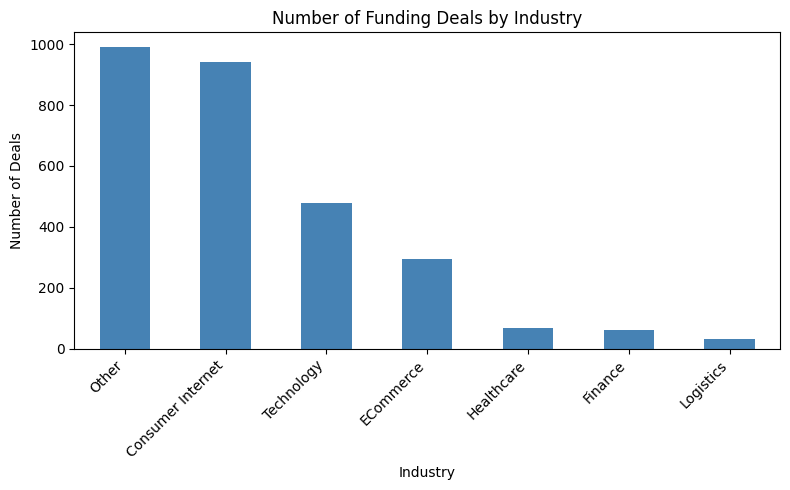

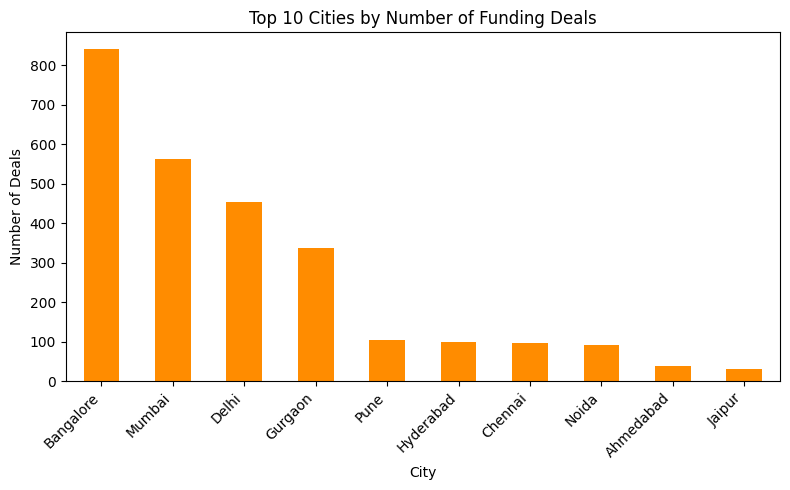

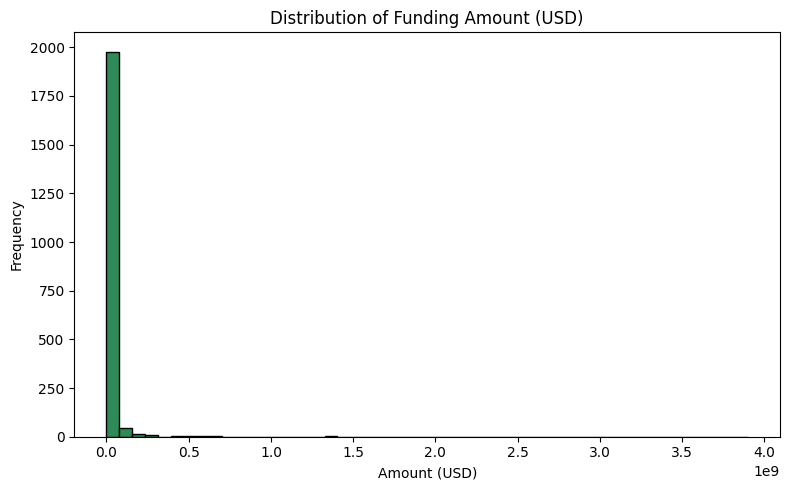

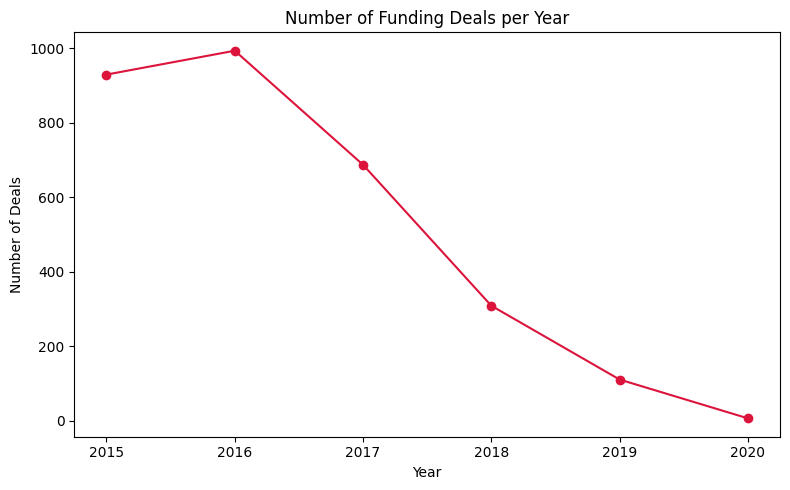


Charts saved: chart_industry_frequency.png, chart_city_frequency.png,
chart_amount_histogram.png, chart_yearly_trend.png
Download these from the Colab Files panel for your report and PPT.


In [ ]:
## ============================================================
## STEP 5a: Descriptive Statistics
## Project: Statistical Analysis of Factors Affecting Startup
##          Funding in India
## ============================================================

import pandas as pd
import matplotlib.pyplot as plt

## ---- 1. Load cleaned data ---------------------------------------------------
df = pd.read_csv("startup_funding_clean.csv")
print("Dataset shape:", df.shape)

## ---- 2. Descriptive statistics for Amount_USD -------------------------------
amount = df["Amount_USD"].dropna()

print("\n===== Descriptive Statistics: Funding Amount (USD) =====")
desc = amount.describe()
print(desc)

print("\nAdditional statistics:")
print("Skewness:", amount.skew())
print("Kurtosis:", amount.kurt())
print("Median:", amount.median())
print("Mode:", amount.mode().values[0] if not amount.mode().empty else "N/A")

# Note for your report: funding amounts are almost always heavily right-skewed
# (a few huge deals, many small ones) — mention this explicitly, it's expected
# and relevant to why you might discuss log-transformation in Regression later.

## ---- 3. Frequency distribution: Industry ------------------------------------
print("\n===== Frequency Distribution: Industry =====")
industry_freq = df["Industry"].value_counts()
industry_pct = df["Industry"].value_counts(normalize=True).mul(100).round(2)
industry_table = pd.DataFrame({"Frequency": industry_freq, "Percentage": industry_pct})
print(industry_table)

## ---- 4. Frequency distribution: City (top 10) -------------------------------
print("\n===== Frequency Distribution: City (Top 10) =====")
city_freq = df["City"].value_counts().head(10)
city_pct = df["City"].value_counts(normalize=True).mul(100).round(2).head(10)
city_table = pd.DataFrame({"Frequency": city_freq, "Percentage": city_pct})
print(city_table)

## ---- 5. Frequency distribution: Investment Type -----------------------------
print("\n===== Frequency Distribution: Investment Type =====")
inv_freq = df["Investment_Type"].value_counts()
inv_pct = df["Investment_Type"].value_counts(normalize=True).mul(100).round(2)
inv_table = pd.DataFrame({"Frequency": inv_freq, "Percentage": inv_pct})
print(inv_table)

## ---- 6. Year-wise funding trend ----------------------------------------------
print("\n===== Number of Deals and Total Funding by Year =====")
year_summary = df.groupby("Year").agg(
    Deal_Count=("Startup_Name", "count"),
    Total_Funding_USD=("Amount_USD", "sum"),
    Avg_Funding_USD=("Amount_USD", "mean")
).round(2)
print(year_summary)

## ---- 7. Charts (save as PNG for your report / PPT) ---------------------------
plt.figure(figsize=(8, 5))
df["Industry"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Number of Funding Deals by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Deals")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("chart_industry_frequency.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
df["City"].value_counts().head(10).plot(kind="bar", color="darkorange")
plt.title("Top 10 Cities by Number of Funding Deals")
plt.xlabel("City")
plt.ylabel("Number of Deals")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("chart_city_frequency.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(amount, bins=50, color="seagreen", edgecolor="black")
plt.title("Distribution of Funding Amount (USD)")
plt.xlabel("Amount (USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("chart_amount_histogram.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
year_summary["Deal_Count"].plot(kind="line", marker="o", color="crimson")
plt.title("Number of Funding Deals per Year")
plt.xlabel("Year")
plt.ylabel("Number of Deals")
plt.tight_layout()
plt.savefig("chart_yearly_trend.png", dpi=200)
plt.show()

print("\nCharts saved: chart_industry_frequency.png, chart_city_frequency.png,")
print("chart_amount_histogram.png, chart_yearly_trend.png")
print("Download these from the Colab Files panel for your report and PPT.")

===== Correlation: Funding Amount vs Year =====
Pearson r (raw amount)  = 0.1000, p-value = 5.454e-06
Pearson r (log amount)  = 0.2176, p-value = 1.725e-23
n = 2059

===== Correlation: Funding Amount vs Number of Investors =====
Pearson r (raw amount)  = 0.0007, p-value = 0.9735
Pearson r (log amount)  = 0.1110, p-value = 5.024e-07
n = 2039

===== Correlation Matrix =====
                     Amount_USD  Log_Amount    Year  Number_of_Investors
Amount_USD               1.0000      0.3419  0.1000               0.0007
Log_Amount               0.3419      1.0000  0.2176               0.1110
Year                     0.1000      0.2176  1.0000              -0.0104
Number_of_Investors      0.0007      0.1110 -0.0104               1.0000


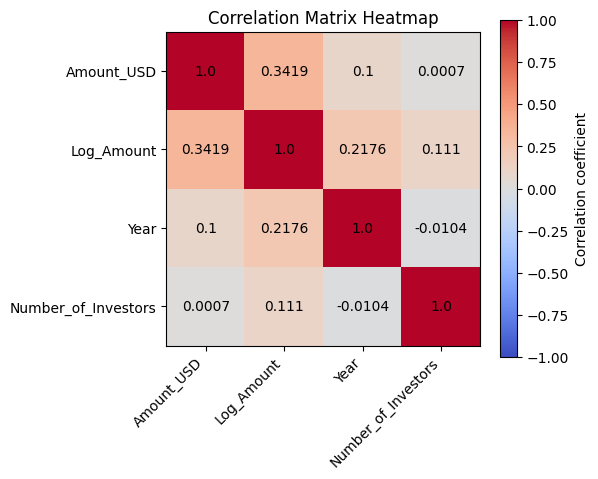

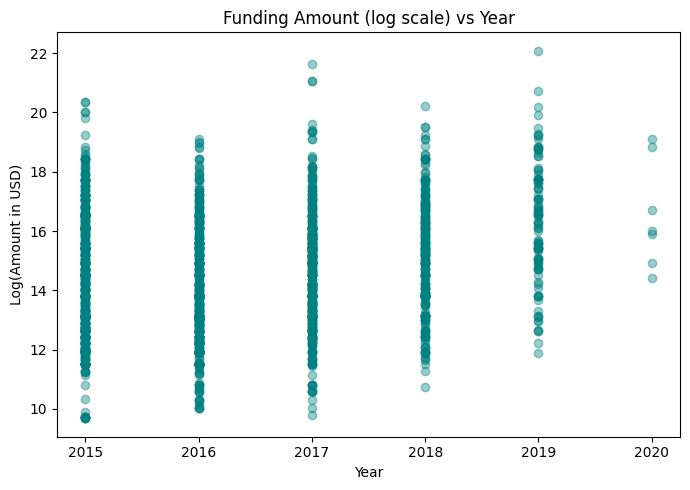


Charts saved: chart_correlation_heatmap.png, chart_scatter_year_amount.png

===== How to read this =====
- If p-value < 0.05: correlation is statistically significant.
- r close to 0 = weak/no linear relationship; closer to +1 or -1 = stronger.
- Use the LOG-amount correlation as your primary reported result, since raw
  amount is heavily skewed by a few huge outlier deals (see Step 5a).


In [ ]:
## ============================================================
## STEP 5b: Correlation Analysis
## Project: Statistical Analysis of Factors Affecting Startup
##          Funding in India
## ============================================================

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

## ---- 1. Load cleaned data ---------------------------------------------------
df = pd.read_csv("startup_funding_clean.csv")

## ---- 2. Build the Number_of_Investors variable -------------------------------
df["Number_of_Investors"] = df["Investors_Name"].apply(
    lambda x: len(str(x).split(",")) if pd.notna(x) else np.nan
)

## ---- 3. Create a log-transformed amount (handles the heavy right-skew we
##         found in Step 5a — skewness was 22.1, so raw correlation can be
##         misleading; log-amount is standard practice for funding/financial data)
df["Log_Amount"] = np.log(df["Amount_USD"])

## ---- 4. Correlation: Amount vs Year -------------------------------------------
sub1 = df.dropna(subset=["Amount_USD", "Year"])
r_raw, p_raw = stats.pearsonr(sub1["Year"], sub1["Amount_USD"])
r_log, p_log = stats.pearsonr(sub1["Year"], sub1["Log_Amount"])

print("===== Correlation: Funding Amount vs Year =====")
print(f"Pearson r (raw amount)  = {r_raw:.4f}, p-value = {p_raw:.4g}")
print(f"Pearson r (log amount)  = {r_log:.4f}, p-value = {p_log:.4g}")
print(f"n = {len(sub1)}")

## ---- 5. Correlation: Amount vs Number of Investors ----------------------------
sub2 = df.dropna(subset=["Amount_USD", "Number_of_Investors"])
r2_raw, p2_raw = stats.pearsonr(sub2["Number_of_Investors"], sub2["Amount_USD"])
r2_log, p2_log = stats.pearsonr(sub2["Number_of_Investors"], sub2["Log_Amount"])

print("\n===== Correlation: Funding Amount vs Number of Investors =====")
print(f"Pearson r (raw amount)  = {r2_raw:.4f}, p-value = {p2_raw:.4g}")
print(f"Pearson r (log amount)  = {r2_log:.4f}, p-value = {p2_log:.4g}")
print(f"n = {len(sub2)}")

## ---- 6. Full correlation matrix (numeric variables) ---------------------------
corr_vars = df[["Amount_USD", "Log_Amount", "Year", "Number_of_Investors"]]
corr_matrix = corr_vars.corr(method="pearson").round(4)
print("\n===== Correlation Matrix =====")
print(corr_matrix)

## ---- 7. Heatmap chart ----------------------------------------------------------
plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation coefficient")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, corr_matrix.iloc[i, j], ha="center", va="center", color="black")
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.savefig("chart_correlation_heatmap.png", dpi=200)
plt.show()

## ---- 8. Scatter plot: Year vs Log_Amount ----------------------------------------
plt.figure(figsize=(7, 5))
plt.scatter(sub1["Year"], sub1["Log_Amount"], alpha=0.4, color="teal")
plt.title("Funding Amount (log scale) vs Year")
plt.xlabel("Year")
plt.ylabel("Log(Amount in USD)")
plt.tight_layout()
plt.savefig("chart_scatter_year_amount.png", dpi=200)
plt.show()

print("\nCharts saved: chart_correlation_heatmap.png, chart_scatter_year_amount.png")

## ---- 9. Quick interpretation guide (for you to adapt into your report) ---------
print("\n===== How to read this =====")
print("- If p-value < 0.05: correlation is statistically significant.")
print("- r close to 0 = weak/no linear relationship; closer to +1 or -1 = stronger.")
print("- Use the LOG-amount correlation as your primary reported result, since raw")
print("  amount is heavily skewed by a few huge outlier deals (see Step 5a).")

Industries included in ANOVA: ['ECommerce', 'Logistics', 'Technology', 'Finance', 'Healthcare', 'Consumer Internet']
Group sizes:
 Industry
Consumer Internet    588
Technology           310
ECommerce            202
Finance               57
Healthcare            44
Logistics             23
Name: count, dtype: int64

H0: Mean funding amount (log) is equal across all industries
H1: At least one industry's mean funding amount differs

===== Assumption Check: Normality (Shapiro-Wilk test on log-amount) =====
ECommerce            n=202   W=0.9861  p=0.04496  (deviates from normal)
Logistics            n=23    W=0.9650  p=0.5723  (normal-ish)
Technology           n=310   W=0.9918  p=0.08372  (normal-ish)
Finance              n=57    W=0.9859  p=0.7443  (normal-ish)
Healthcare           n=44    W=0.9739  p=0.4123  (normal-ish)
Consumer Internet    n=588   W=0.9815  p=8.793e-07  (deviates from normal)

===== Assumption Check: Homogeneity of Variance (Levene's test) =====
Levene statistic = 0.69

<Figure size 900x500 with 0 Axes>

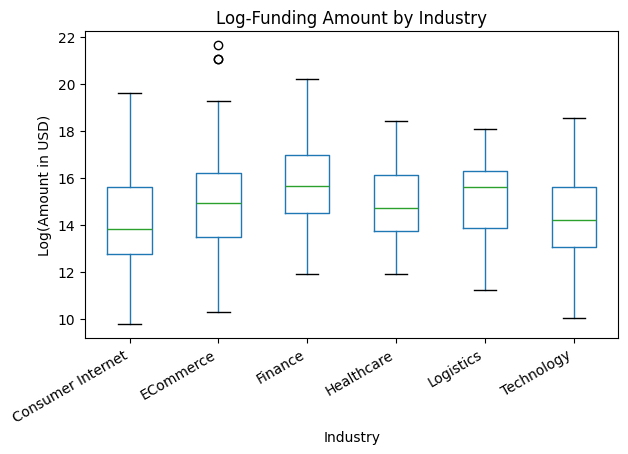


Chart saved: chart_anova_boxplot.png


In [ ]:
## ============================================================
## STEP 5c: One-Way ANOVA
## Question: Does average funding amount differ significantly
##           across industries?
## Project: Statistical Analysis of Factors Affecting Startup
##          Funding in India
## ============================================================

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

## ---- 1. Load cleaned data & prepare -------------------------------------------
df = pd.read_csv("startup_funding_clean.csv")
df["Log_Amount"] = np.log(df["Amount_USD"])

# Drop rows with missing amount or industry, and exclude "Other" since it's a
# mixed bag of unrelated categories, not a meaningful group for comparison
data = df.dropna(subset=["Amount_USD", "Industry"])
data = data[data["Industry"] != "Other"]

industries = data["Industry"].unique().tolist()
print("Industries included in ANOVA:", industries)
print("Group sizes:\n", data["Industry"].value_counts())

## ---- 2. State hypotheses --------------------------------------------------------
print("\nH0: Mean funding amount (log) is equal across all industries")
print("H1: At least one industry's mean funding amount differs\n")

## ---- 3. Assumption check 1: Normality (Shapiro-Wilk per group) -----------------
print("===== Assumption Check: Normality (Shapiro-Wilk test on log-amount) =====")
for ind in industries:
    group_vals = data.loc[data["Industry"] == ind, "Log_Amount"]
    if len(group_vals) >= 3:
        stat, p = stats.shapiro(group_vals)
        print(f"{ind:<20} n={len(group_vals):<5} W={stat:.4f}  p={p:.4g}  "
              f"{'(normal-ish)' if p > 0.05 else '(deviates from normal)'}")

## ---- 4. Assumption check 2: Homogeneity of variance (Levene's test) -----------
groups = [data.loc[data["Industry"] == ind, "Log_Amount"] for ind in industries]
levene_stat, levene_p = stats.levene(*groups)
print(f"\n===== Assumption Check: Homogeneity of Variance (Levene's test) =====")
print(f"Levene statistic = {levene_stat:.4f}, p-value = {levene_p:.4g}")
print("Note: ANOVA is fairly robust to mild violations of this assumption when")
print("group sizes are reasonably large, as here.")

## ---- 5. Run the One-Way ANOVA ----------------------------------------------------
f_stat, anova_p = stats.f_oneway(*groups)
print(f"\n===== One-Way ANOVA Result =====")
print(f"F-statistic = {f_stat:.4f}")
print(f"p-value     = {anova_p:.4g}")
if anova_p < 0.05:
    print("Result: statistically significant -> reject H0. At least one industry's")
    print("mean funding differs from the others.")
else:
    print("Result: not statistically significant -> fail to reject H0.")

## ---- 6. Post-hoc test (Tukey HSD) — only meaningful if ANOVA is significant ----
if anova_p < 0.05:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    tukey = pairwise_tukeyhsd(endog=data["Log_Amount"], groups=data["Industry"], alpha=0.05)
    print("\n===== Post-Hoc Test: Tukey HSD (pairwise comparisons) =====")
    print(tukey)

## ---- 7. Descriptive summary by group (for your report table) -------------------
summary = data.groupby("Industry")["Amount_USD"].agg(
    N="count", Mean="mean", Median="median", SD="std"
).round(2)
print("\n===== Mean Funding Amount by Industry (raw USD, for reporting) =====")
print(summary)

## ---- 8. Boxplot chart -------------------------------------------------------------
plt.figure(figsize=(9, 5))
data.boxplot(column="Log_Amount", by="Industry", grid=False)
plt.title("Log-Funding Amount by Industry")
plt.suptitle("")
plt.xlabel("Industry")
plt.ylabel("Log(Amount in USD)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("chart_anova_boxplot.png", dpi=200)
plt.show()

print("\nChart saved: chart_anova_boxplot.png")

Year centered on mean = 2016.76
Final regression sample size: 1221

===== Regression Model Summary =====
                            OLS Regression Results                            
Dep. Variable:             Log_Amount   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     132.0
Date:                Thu, 16 Jul 2026   Prob (F-statistic):          5.36e-221
Time:                        17:00:57   Log-Likelihood:                -2007.1
No. Observations:                1221   AIC:                             4042.
Df Residuals:                    1207   BIC:                             4114.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
--

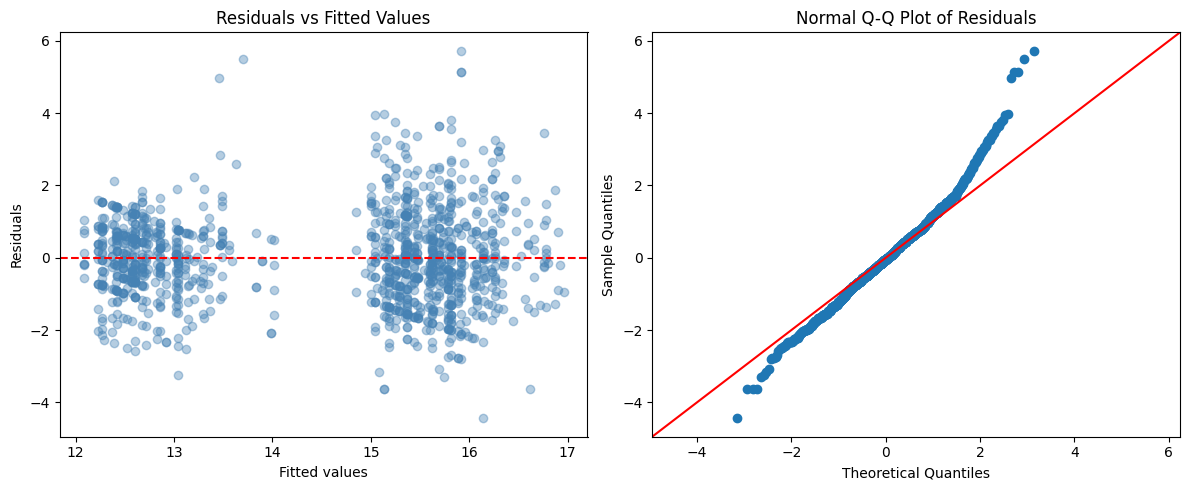


Chart saved: chart_regression_diagnostics.png

===== How to interpret coefficients =====
- Coefficients are in LOG scale. A coefficient of 0.5 for a category means
  funding is roughly exp(0.5)=1.65x higher than the reference category,
  holding other variables constant.
- Reference categories: Industry=Consumer Internet, City=Bangalore,
  Investment Type=Private Equity. Year is CENTERED on its mean, so the
  intercept represents an average-year deal, not year zero.
- Look at the 'P>|t|' column in the summary table: values < 0.05 mean that
  predictor is a statistically significant driver of funding amount.


In [ ]:
## ============================================================
## STEP 5d: Multiple Linear Regression
## Question: Do Industry, City, Investment Type, and Year
##           predict funding amount?
## Project: Statistical Analysis of Factors Affecting Startup
##          Funding in India
## ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

## ---- 1. Load cleaned data & prepare ---------------------------------------------
df = pd.read_csv("startup_funding_clean.csv")
df["Log_Amount"] = np.log(df["Amount_USD"])

## ---- 2. Keep only top categories to keep the model interpretable ----------------
top_cities = ["Bangalore", "Mumbai", "Delhi", "Gurgaon", "Pune"]
top_investment_types = ["Seed Funding", "Private Equity"]  # the two dominant types

data = df.dropna(subset=["Log_Amount", "Industry", "City", "Investment_Type", "Year"]).copy()
data = data[data["Industry"] != "Other"]
data["City_grouped"] = np.where(data["City"].isin(top_cities), data["City"], "Other_City")
data["InvType_grouped"] = np.where(
    data["Investment_Type"].isin(top_investment_types), data["Investment_Type"], "Other_Type"
)

# Center Year around its mean. Raw years (2015-2020) are far from zero, which
# creates near-collinearity with the intercept and produces a meaningless,
# huge-standard-error intercept plus a "large condition number" warning.
# Centering fixes this without changing the slope, R-squared, or p-values.
mean_year = data["Year"].mean()
data["Year_centered"] = data["Year"] - mean_year
print(f"Year centered on mean = {mean_year:.2f}")

print("Final regression sample size:", len(data))

## ---- 3. Fit the model using formula API (auto-creates dummy variables) ----------
# Reference categories: Industry = Consumer Internet, City = Bangalore,
# Investment Type = Private Equity (statsmodels picks the first alphabetically
# unless we set it explicitly — we set it explicitly below for clean interpretation)
data["Industry"] = pd.Categorical(
    data["Industry"], categories=["Consumer Internet"] + [c for c in data["Industry"].unique() if c != "Consumer Internet"]
)
data["City_grouped"] = pd.Categorical(
    data["City_grouped"], categories=["Bangalore"] + [c for c in data["City_grouped"].unique() if c != "Bangalore"]
)
data["InvType_grouped"] = pd.Categorical(
    data["InvType_grouped"], categories=["Private Equity"] + [c for c in data["InvType_grouped"].unique() if c != "Private Equity"]
)

model = smf.ols(
    "Log_Amount ~ C(Industry) + C(City_grouped) + C(InvType_grouped) + Year_centered",
    data=data
).fit()

print("\n===== Regression Model Summary =====")
print(model.summary())

## ---- 4. Key numbers pulled out for easy reporting -------------------------------
print("\n===== Key Model Fit Statistics =====")
print(f"R-squared          = {model.rsquared:.4f}")
print(f"Adjusted R-squared = {model.rsquared_adj:.4f}")
print(f"F-statistic        = {model.fvalue:.4f}, p-value = {model.f_pvalue:.4g}")
print(f"n = {int(model.nobs)}")

## ---- 5. Assumption checks --------------------------------------------------------
# Residual normality
resid = model.resid
from scipy import stats
shapiro_stat, shapiro_p = stats.shapiro(resid.sample(min(len(resid), 5000), random_state=1))
print(f"\nShapiro-Wilk on residuals: W={shapiro_stat:.4f}, p={shapiro_p:.4g} "
      f"({'residuals roughly normal' if shapiro_p > 0.05 else 'residuals deviate from normal — note as limitation'})")

# Multicollinearity check (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = sm.add_constant(pd.get_dummies(data[["Industry", "City_grouped", "InvType_grouped", "Year_centered"]], drop_first=True).astype(float))
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\n===== Variance Inflation Factors (VIF) — check for multicollinearity =====")
print(vif_data)
print("Rule of thumb: VIF > 10 signals a multicollinearity concern.")

## ---- 6. Diagnostic plots ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(model.fittedvalues, resid, alpha=0.4, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuals vs Fitted Values")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")

sm.qqplot(resid, line="45", ax=axes[1])
axes[1].set_title("Normal Q-Q Plot of Residuals")

plt.tight_layout()
plt.savefig("chart_regression_diagnostics.png", dpi=200)
plt.show()

print("\nChart saved: chart_regression_diagnostics.png")

## ---- 7. Plain-language guide for interpretation ------------------------------------
print("\n===== How to interpret coefficients =====")
print("- Coefficients are in LOG scale. A coefficient of 0.5 for a category means")
print("  funding is roughly exp(0.5)=1.65x higher than the reference category,")
print("  holding other variables constant.")
print("- Reference categories: Industry=Consumer Internet, City=Bangalore,")
print("  Investment Type=Private Equity. Year is CENTERED on its mean, so the")
print("  intercept represents an average-year deal, not year zero.")
print("- Look at the 'P>|t|' column in the summary table: values < 0.05 mean that")
print("  predictor is a statistically significant driver of funding amount.")

Sample size for Chi-Square test: 1823

===== Contingency Table: Industry x Investment Type =====
Investment_Type    Private Equity  Seed Funding
Industry                                       
Consumer Internet             393           538
ECommerce                     152           121
Finance                        30            20
Healthcare                     36            32
Logistics                      18            13
Technology                    240           230

H0: Industry and Investment Type are independent (no association)
H1: Industry and Investment Type are NOT independent (there is an association)

===== Chi-Square Test Result =====
Chi-square statistic = 25.4500
Degrees of freedom   = 5
p-value              = 0.000114

===== Expected Frequencies (under H0) =====
Investment_Type    Private Equity  Seed Funding
Industry                                       
Consumer Internet          443.80        487.20
ECommerce                  130.14        142.86
Finance     

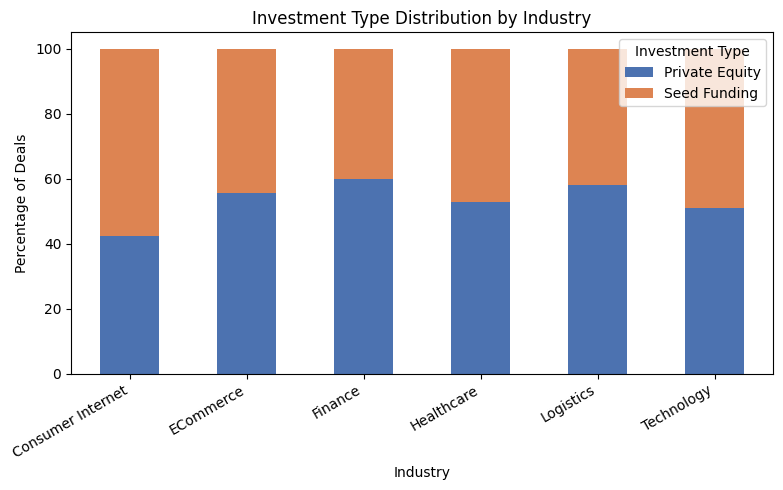


Chart saved: chart_chisquare_stacked_bar.png


In [ ]:
## ============================================================
## STEP 5e: Chi-Square Test of Independence
## Question: Is there an association between Industry and
##           Investment Type?
## Project: Statistical Analysis of Factors Affecting Startup
##          Funding in India
## ============================================================

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

## ---- 1. Load cleaned data & prepare ---------------------------------------------
df = pd.read_csv("startup_funding_clean.csv")

## ---- 2. Restrict to categories with reasonable sample sizes ---------------------
# Using the same top industries as before, and the two dominant investment
# types, so expected cell counts are large enough for a valid Chi-Square test
top_investment_types = ["Seed Funding", "Private Equity"]

data = df.dropna(subset=["Industry", "Investment_Type"]).copy()
data = data[data["Industry"] != "Other"]
data = data[data["Investment_Type"].isin(top_investment_types)]

print("Sample size for Chi-Square test:", len(data))

## ---- 3. Build the contingency table ---------------------------------------------
contingency = pd.crosstab(data["Industry"], data["Investment_Type"])
print("\n===== Contingency Table: Industry x Investment Type =====")
print(contingency)

## ---- 4. State hypotheses ----------------------------------------------------------
print("\nH0: Industry and Investment Type are independent (no association)")
print("H1: Industry and Investment Type are NOT independent (there is an association)\n")

## ---- 5. Run the Chi-Square test ----------------------------------------------------
chi2, p, dof, expected = stats.chi2_contingency(contingency)

print("===== Chi-Square Test Result =====")
print(f"Chi-square statistic = {chi2:.4f}")
print(f"Degrees of freedom   = {dof}")
print(f"p-value              = {p:.4g}")

expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns).round(2)
print("\n===== Expected Frequencies (under H0) =====")
print(expected_df)

min_expected = expected.min()
print(f"\nSmallest expected cell count = {min_expected:.2f} "
      f"({'OK - assumption met (>5)' if min_expected >= 5 else 'CAUTION - below 5, interpret with care'})")

if p < 0.05:
    print("\nResult: statistically significant -> reject H0. There IS an association")
    print("between Industry and Investment Type.")
else:
    print("\nResult: not statistically significant -> fail to reject H0. No evidence")
    print("of association between Industry and Investment Type.")

## ---- 6. Effect size: Cramer's V ------------------------------------------------------
n = contingency.sum().sum()
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"\nCramer's V (effect size) = {cramers_v:.4f}")
print("Guide: 0.1=small, 0.3=medium, 0.5=large association")

## ---- 7. Row-percentage table (easier to interpret / present) --------------------------
row_pct = pd.crosstab(data["Industry"], data["Investment_Type"], normalize="index").mul(100).round(1)
print("\n===== Row Percentages (% of each industry's deals by investment type) =====")
print(row_pct)

## ---- 8. Stacked bar chart --------------------------------------------------------------
row_pct.plot(kind="bar", stacked=True, figsize=(8, 5), color=["#4C72B0", "#DD8452"])
plt.title("Investment Type Distribution by Industry")
plt.xlabel("Industry")
plt.ylabel("Percentage of Deals")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Investment Type")
plt.tight_layout()
plt.savefig("chart_chisquare_stacked_bar.png", dpi=200)
plt.show()

print("\nChart saved: chart_chisquare_stacked_bar.png")

Group sizes: Bangalore n = 582  | Mumbai n = 397

H0: Mean funding amount (log) is equal for Bangalore and Mumbai startups
H1: Mean funding amount (log) differs between Bangalore and Mumbai startups

===== Assumption Check: Normality (Shapiro-Wilk on log-amount) =====
Bangalore: W=0.9838, p=4.487e-06 (deviates from normal)
Mumbai:    W=0.9902, p=0.009285 (deviates from normal)
Note: with n>500 in both groups, the t-test is robust to mild non-normality
via the Central Limit Theorem.

===== Assumption Check: Equal Variances (Levene's test) =====
Levene statistic = 0.0005, p-value = 0.9829
-> Variances are roughly equal, using standard t-test

===== Independent Samples t-Test Result =====
t-statistic = 1.9292
p-value     = 0.054
Result: not statistically significant -> fail to reject H0. No evidence
of a difference in average funding between the two cities.

Cohen's d (effect size) = 0.1256
Guide: 0.2=small, 0.5=medium, 0.8=large effect

===== Descriptive Summary (raw USD, for reporting) 

<Figure size 600x500 with 0 Axes>

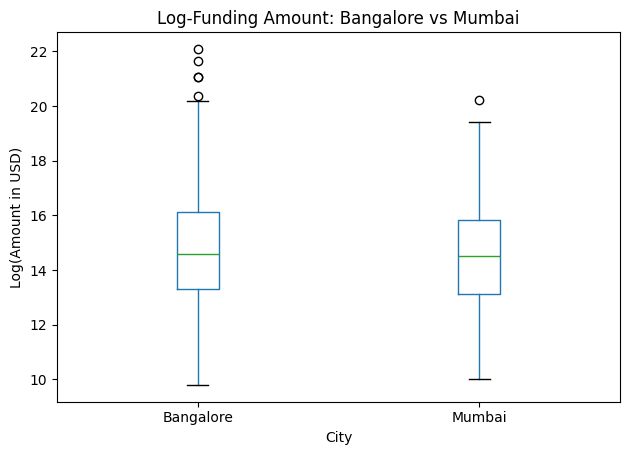


Chart saved: chart_ttest_boxplot.png


In [ ]:
## ============================================================
## STEP 5f: Independent Samples t-Test
## Question: Does average funding amount differ between
##           Bangalore and Mumbai startups?
## Project: Statistical Analysis of Factors Affecting Startup
##          Funding in India
## ============================================================

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

## ---- 1. Load cleaned data & prepare ---------------------------------------------
df = pd.read_csv("startup_funding_clean.csv")
df["Log_Amount"] = np.log(df["Amount_USD"])

data = df.dropna(subset=["Amount_USD", "City"])
data = data[data["City"].isin(["Bangalore", "Mumbai"])]

bangalore = data.loc[data["City"] == "Bangalore", "Log_Amount"]
mumbai = data.loc[data["City"] == "Mumbai", "Log_Amount"]

print("Group sizes: Bangalore n =", len(bangalore), " | Mumbai n =", len(mumbai))

## ---- 2. State hypotheses ----------------------------------------------------------
print("\nH0: Mean funding amount (log) is equal for Bangalore and Mumbai startups")
print("H1: Mean funding amount (log) differs between Bangalore and Mumbai startups\n")

## ---- 3. Assumption check 1: Normality (Shapiro-Wilk) -------------------------------
sb_stat, sb_p = stats.shapiro(bangalore)
sm_stat, sm_p = stats.shapiro(mumbai)
print("===== Assumption Check: Normality (Shapiro-Wilk on log-amount) =====")
print(f"Bangalore: W={sb_stat:.4f}, p={sb_p:.4g} "
      f"({'normal-ish' if sb_p > 0.05 else 'deviates from normal'})")
print(f"Mumbai:    W={sm_stat:.4f}, p={sm_p:.4g} "
      f"({'normal-ish' if sm_p > 0.05 else 'deviates from normal'})")
print("Note: with n>500 in both groups, the t-test is robust to mild non-normality")
print("via the Central Limit Theorem.")

## ---- 4. Assumption check 2: Equal variances (Levene's test) -------------------------
levene_stat, levene_p = stats.levene(bangalore, mumbai)
print(f"\n===== Assumption Check: Equal Variances (Levene's test) =====")
print(f"Levene statistic = {levene_stat:.4f}, p-value = {levene_p:.4g}")
equal_var = levene_p > 0.05
print(f"-> {'Variances are roughly equal, using standard t-test' if equal_var else 'Variances differ, using Welch t-test (does not assume equal variance)'}")

## ---- 5. Run the t-test ------------------------------------------------------------------
t_stat, p_val = stats.ttest_ind(bangalore, mumbai, equal_var=equal_var)
df_ttest = len(bangalore) + len(mumbai) - 2

print(f"\n===== Independent Samples t-Test Result =====")
print(f"t-statistic = {t_stat:.4f}")
print(f"p-value     = {p_val:.4g}")
if p_val < 0.05:
    print("Result: statistically significant -> reject H0. Average funding amount")
    print("differs significantly between Bangalore and Mumbai startups.")
else:
    print("Result: not statistically significant -> fail to reject H0. No evidence")
    print("of a difference in average funding between the two cities.")

## ---- 6. Effect size: Cohen's d -----------------------------------------------------------
pooled_std = np.sqrt(((len(bangalore) - 1) * bangalore.std()**2 +
                       (len(mumbai) - 1) * mumbai.std()**2) /
                      (len(bangalore) + len(mumbai) - 2))
cohens_d = (bangalore.mean() - mumbai.mean()) / pooled_std
print(f"\nCohen's d (effect size) = {cohens_d:.4f}")
print("Guide: 0.2=small, 0.5=medium, 0.8=large effect")

## ---- 7. Descriptive summary table (for your report) -----------------------------------------
summary = data.groupby("City")["Amount_USD"].agg(N="count", Mean="mean", Median="median", SD="std").round(2)
print("\n===== Descriptive Summary (raw USD, for reporting) =====")
print(summary)

## ---- 8. Boxplot chart ----------------------------------------------------------------------
plt.figure(figsize=(6, 5))
data.boxplot(column="Log_Amount", by="City", grid=False)
plt.title("Log-Funding Amount: Bangalore vs Mumbai")
plt.suptitle("")
plt.xlabel("City")
plt.ylabel("Log(Amount in USD)")
plt.tight_layout()
plt.savefig("chart_ttest_boxplot.png", dpi=200)
plt.show()

print("\nChart saved: chart_ttest_boxplot.png")